<a href="https://colab.research.google.com/github/rifahnanjiba02-arch/cse465/blob/main/KERAS/Keras_cifar10.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Implementing feedforward neural networks with Keras and TensorFlow

In [3]:
# import the necessary packages
from sklearn.preprocessing import LabelBinarizer
from sklearn.metrics import classification_report
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input
from tensorflow.keras.optimizers import SGD
from tensorflow.keras.datasets import cifar10

import matplotlib.pyplot as plt
import numpy as np

In [4]:
print("[INFO] loading CIFAR-10 data...")

(trainX, trainY), (testX, testY) = cifar10.load_data()

print("Original train shape:", trainX.shape)
print("Original test shape:", testX.shape)

# scale pixel values to [0,1]
trainX = trainX.astype("float32") / 255.0
testX = testX.astype("float32") / 255.0

# Flatten images
trainX = trainX.reshape(trainX.shape[0], 3072)
testX = testX.reshape(testX.shape[0], 3072)

print("Flattened train shape:", trainX.shape)
print("Flattened test shape:", testX.shape)

[INFO] loading CIFAR-10 data...
170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 29s 0us/step
Original train shape: (50000, 32, 32, 3)
Original test shape: (10000, 32, 32, 3)
Flattened train shape: (50000, 3072)
Flattened test shape: (10000, 3072)


In [5]:
# Convert labels to one-hot vectors
lb = LabelBinarizer()

trainY = lb.fit_transform(trainY.ravel())
testY = lb.transform(testY.ravel())

# Class names
labelNames = [
    "airplane",
    "automobile",
    "bird",
    "cat",
    "deer",
    "dog",
    "frog",
    "horse",
    "ship",
    "truck"
]


In [6]:
# Define the neural network
model = Sequential([
    Input(shape=(3072,)),
    Dense(1024, activation="relu"),
    Dense(512, activation="relu"),
    Dense(10, activation="softmax")
])

model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 1024)           │     3,146,752 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 512)            │       524,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │         5,130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,676,682 (14.03 MB)

 Trainable params: 3,676,682 (14.03 MB)

 Non-trainable params: 0 (0.00 B)

In [7]:
sgd = SGD(learning_rate=0.01)

model.compile(
    loss="categorical_crossentropy",
    optimizer=sgd,
    metrics=["accuracy"]
)

# Train

In [8]:
print("[INFO] training network...")

H = model.fit(
    trainX,
    trainY,
    validation_data=(testX, testY),
    epochs=100,
    batch_size=32,
    verbose=1
)

[INFO] training network...
Epoch 1/100
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 25s 16ms/step - accuracy: 0.3450 - loss: 1.8371 - val_accuracy: 0.3446 - val_loss: 1.8204
Epoch 2/100
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 29s 18ms/step - accuracy: 0.4144 - loss: 1.6534 - val_accuracy: 0.4082 - val_loss: 1.6800
Epoch 3/100
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 34s 22ms/step - accuracy: 0.4441 - loss: 1.5743 - val_accuracy: 0.4240 - val_loss: 1.6186
Epoch 4/100
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 24s 15ms/step - accuracy: 0.4625 - loss: 1.5163 - val_accuracy: 0.4193 - val_loss: 1.6281
Epoch 5/100
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 24s 16ms/step - accuracy: 0.4813 - loss: 1.4687 - val_accuracy: 0.4602 - val_loss: 1.5165
Epoch 6/100
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 42s 16ms/step - accuracy: 0.4969 - loss: 1.4271 - val_accuracy: 0.4778 - val_loss: 1.4718
Epoch 7/100
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 25s 16ms/step - accuracy: 0.5084 - loss: 1.3910 - val_accuracy: 0.4529 - val_loss: 1.5172
Epoch 8/100
1563/1563 ━━━━━━━━━━━━━━━━━━━━

# Evaluation

In [9]:
print("[INFO] evaluating network...")

predictions = model.predict(testX, batch_size=32)

print(
    classification_report(
        testY.argmax(axis=1),
        predictions.argmax(axis=1),
        target_names=labelNames
    )
)


[INFO] evaluating network...
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step
              precision    recall  f1-score   support

    airplane       0.64      0.65      0.64      1000
  automobile       0.69      0.69      0.69      1000
        bird       0.43      0.52      0.47      1000
         cat       0.38      0.42      0.40      1000
        deer       0.56      0.44      0.49      1000
         dog       0.45      0.52      0.48      1000
        frog       0.63      0.61      0.62      1000
       horse       0.68      0.59      0.63      1000
        ship       0.68      0.73      0.70      1000
       truck       0.65      0.55      0.59      1000

    accuracy                           0.57     10000
   macro avg       0.58      0.57      0.57     10000
weighted avg       0.58      0.57      0.57     10000



# Plot loss and accuracy

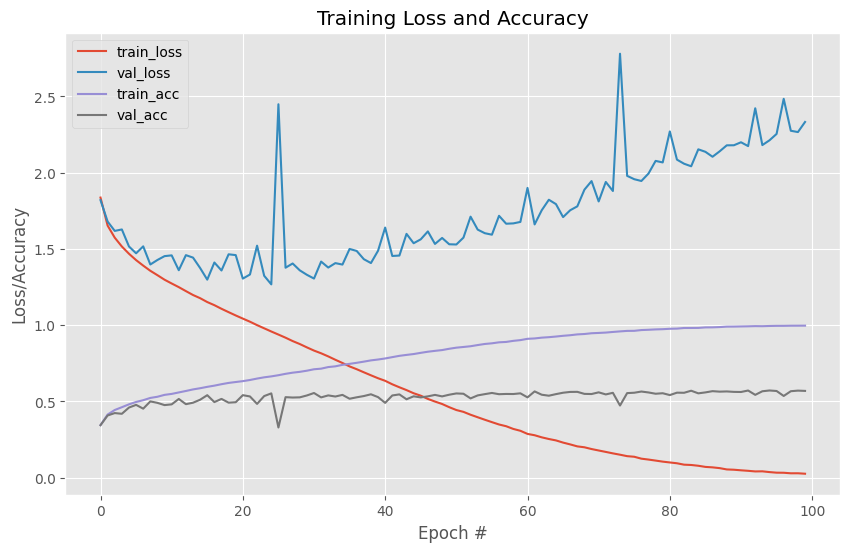

In [10]:
plt.style.use("ggplot")

plt.figure(figsize=(10, 6))

plt.plot(
    np.arange(0, 100),
    H.history["loss"],
    label="train_loss"
)

plt.plot(
    np.arange(0, 100),
    H.history["val_loss"],
    label="val_loss"
)

plt.plot(
    np.arange(0, 100),
    H.history["accuracy"],
    label="train_acc"
)

plt.plot(
    np.arange(0, 100),
    H.history["val_accuracy"],
    label="val_acc"
)

plt.title("Training Loss and Accuracy")
plt.xlabel("Epoch #")
plt.ylabel("Loss/Accuracy")
plt.legend()

plt.show()